# Initial Model Tuning

In [1]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

with open('../data/processed_graphs.pkl', 'rb') as f:
    save_data = pickle.load(f)

split_datasets = save_data['split_datasets']
thresholds = save_data['thresholds']

# Normalize ages using training set stats
train_ages = [g.y.item() for g in split_datasets[0.3]['train']]
age_mean = np.mean(train_ages)
age_std = np.std(train_ages)

for t in thresholds:
    for split in ['train', 'val', 'test']:
        for g in split_datasets[t][split]:
            g.y = torch.tensor([(g.y.item() - age_mean) / age_std], dtype=torch.float)

# Verify clean data
nan_count = sum(1 for g in split_datasets[0.3]['train'] if torch.isnan(g.x).any())
print(f'NaN graphs: {nan_count}')
print(f'Age normalized — mean: {age_mean:.2f}, std: {age_std:.2f}')

NaN graphs: 0
Age normalized — mean: 16.68, std: 6.97


In [2]:
class BrainAgeGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64):
        super().__init__()
        
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        
        self.fc = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, data):
        x = data.x.clone()
        edge_index = data.edge_index.clone()
        batch = data.batch
        
        x = self.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.relu(self.bn2(self.conv2(x, edge_index)))
        
        x = global_mean_pool(x, batch)
        x = self.fc(x)
        
        return x.squeeze()

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        pred = model(batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            pred = model(batch)
            loss = loss_fn(pred, batch.y)
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

### Edge Correlation Threshold of 0

In [3]:
model = BrainAgeGNN(num_node_features=200)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_loader = DataLoader(split_datasets[0.0]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.0]['val'], batch_size=8)

train_losses = []
val_losses = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.4611 | Val Loss: 0.7803
Epoch  20 | Train Loss: 0.4038 | Val Loss: 0.7876
Epoch  30 | Train Loss: 0.2937 | Val Loss: 1.5753
Epoch  40 | Train Loss: 0.2583 | Val Loss: 1.6520
Epoch  50 | Train Loss: 0.3194 | Val Loss: 1.3401
Epoch  60 | Train Loss: 0.2137 | Val Loss: 0.6541
Epoch  70 | Train Loss: 0.2906 | Val Loss: 0.6203
Epoch  80 | Train Loss: 0.2345 | Val Loss: 1.2495
Epoch  90 | Train Loss: 0.2301 | Val Loss: 0.9023
Epoch 100 | Train Loss: 0.2054 | Val Loss: 0.5509


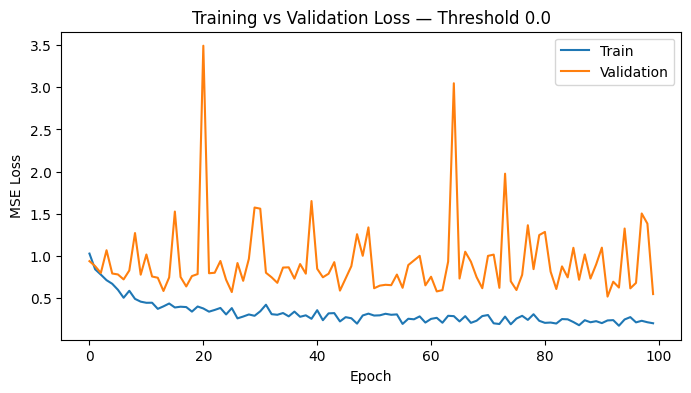

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.0')
plt.legend()
plt.show()

### Edge Correlation Threshold of 0.2

In [5]:
train_loader = DataLoader(split_datasets[0.2]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.2]['val'], batch_size=8)

train_losses_02 = []
val_losses_02 = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses_02.append(train_loss)
    val_losses_02.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.1618 | Val Loss: 0.7113
Epoch  20 | Train Loss: 0.1929 | Val Loss: 1.0997
Epoch  30 | Train Loss: 0.2134 | Val Loss: 0.8318
Epoch  40 | Train Loss: 0.2131 | Val Loss: 0.8980
Epoch  50 | Train Loss: 0.1567 | Val Loss: 0.7319
Epoch  60 | Train Loss: 0.1773 | Val Loss: 0.6521
Epoch  70 | Train Loss: 0.1719 | Val Loss: 1.1036
Epoch  80 | Train Loss: 0.1565 | Val Loss: 1.3057
Epoch  90 | Train Loss: 0.2070 | Val Loss: 0.7203
Epoch 100 | Train Loss: 0.1692 | Val Loss: 0.7374


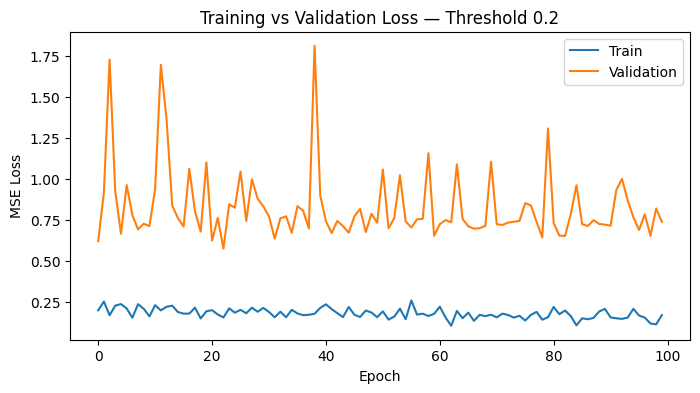

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_02, label='Train')
plt.plot(val_losses_02, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.2')
plt.legend()
plt.show()

### Edge Correlation Threshold of 0.3

In [7]:
train_loader = DataLoader(split_datasets[0.3]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.3]['val'], batch_size=8)

train_losses_03 = []
val_losses_03 = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses_03.append(train_loss)
    val_losses_03.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.1241 | Val Loss: 0.7482
Epoch  20 | Train Loss: 0.1171 | Val Loss: 0.7095
Epoch  30 | Train Loss: 0.1190 | Val Loss: 0.7891
Epoch  40 | Train Loss: 0.1669 | Val Loss: 0.8582
Epoch  50 | Train Loss: 0.1313 | Val Loss: 0.8533
Epoch  60 | Train Loss: 0.1705 | Val Loss: 0.8268
Epoch  70 | Train Loss: 0.1306 | Val Loss: 0.7906
Epoch  80 | Train Loss: 0.1305 | Val Loss: 0.9852
Epoch  90 | Train Loss: 0.1150 | Val Loss: 0.7174
Epoch 100 | Train Loss: 0.1398 | Val Loss: 0.7918


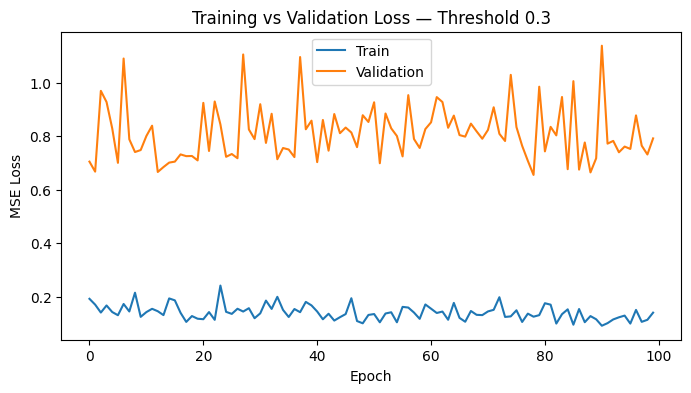

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_03, label='Train')
plt.plot(val_losses_03, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.3')
plt.legend()
plt.show()

### Edge Correlation Threshold of 0.4

In [10]:
train_loader = DataLoader(split_datasets[0.4]['train'], batch_size=8, shuffle=True)
val_loader = DataLoader(split_datasets[0.4]['val'], batch_size=8)

train_losses_04 = []
val_losses_04 = []

for epoch in range(1, 101):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    train_losses_04.append(train_loss)
    val_losses_04.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch  10 | Train Loss: 0.1683 | Val Loss: 0.7438
Epoch  20 | Train Loss: 0.1347 | Val Loss: 0.7569
Epoch  30 | Train Loss: 0.1784 | Val Loss: 0.7110
Epoch  40 | Train Loss: 0.1345 | Val Loss: 0.9118
Epoch  50 | Train Loss: 0.1373 | Val Loss: 0.7671
Epoch  60 | Train Loss: 0.1007 | Val Loss: 0.6523
Epoch  70 | Train Loss: 0.1617 | Val Loss: 0.7178
Epoch  80 | Train Loss: 0.1537 | Val Loss: 0.7328
Epoch  90 | Train Loss: 0.0917 | Val Loss: 0.6789
Epoch 100 | Train Loss: 0.1266 | Val Loss: 0.7292


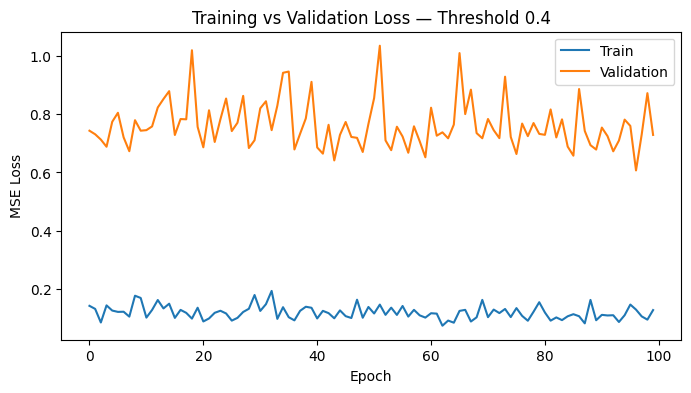

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_04, label='Train')
plt.plot(val_losses_04, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss — Threshold 0.4')
plt.legend()
plt.show()

In [12]:
import pandas as pd

results = {
    'Threshold': [0.0, 0.2, 0.3, 0.4],
    'Final Train Loss': [train_losses[-1], train_losses_02[-1], train_losses_03[-1], train_losses_04[-1]],
    'Best Val Loss': [min(val_losses), min(val_losses_02), min(val_losses_03), min(val_losses_04)],
    'Final Val Loss': [val_losses[-1], val_losses_02[-1], val_losses_03[-1], val_losses_04[-1]],
    'Val Loss Std': [np.std(val_losses), np.std(val_losses_02), np.std(val_losses_03), np.std(val_losses_04)],
    'Edges (per subject)': [39800, 17432, 9450, 4516]
}

comparison = pd.DataFrame(results)
comparison = comparison.round(4)
print(comparison.to_string(index=False))

 Threshold  Final Train Loss  Best Val Loss  Final Val Loss  Val Loss Std  Edges (per subject)
       0.0            0.2054         0.5209          0.5509        0.4323                39800
       0.2            0.1692         0.5735          0.7374        0.2155                17432
       0.3            0.1398         0.6551          0.7918        0.1029                 9450
       0.4            0.1266         0.6071          0.7292        0.0816                 4516


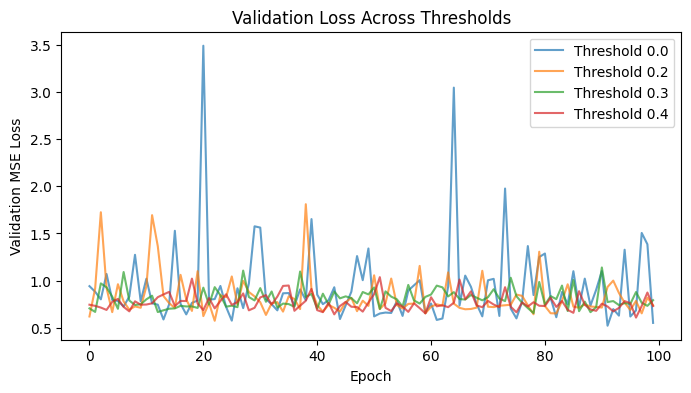

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(val_losses, label='Threshold 0.0', alpha=0.7)
plt.plot(val_losses_02, label='Threshold 0.2', alpha=0.7)
plt.plot(val_losses_03, label='Threshold 0.3', alpha=0.7)
plt.plot(val_losses_04, label='Threshold 0.4', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation MSE Loss')
plt.title('Validation Loss Across Thresholds')
plt.legend()
plt.show()